In [1]:
%load_ext autoreload
%autoreload 2

from hubble_utils import load_quasar_data
import pandas as pd
import numpy as np

#agn_df = load_quasar_data("results/aug10_stonebwb_N30w2000s1000t6c4.h5", populate_sdss=True, apply_cut=False)
agn_df = load_quasar_data("results/data/aug12_chisq_qscpu_N20w4000s1000t8c4.h5", populate_sdss=False, apply_cut=False)

Reading quasars from HDF5: 100%|██████████| 2160/2160 [00:06<00:00, 310.35it/s]

Number of quasars loaded: 2160
Length of colin_df: 189
Number with apparent_mag_2500 > 0: 189
Length of merged DataFrame: 2160
object_id not in merged: ['1447862', '1430781', '1447432', '1445506', '1410489', '1434549', '1447034', '1437865', '1415806', '1447167', '1444732', '1432822', '1452185', '1398586', '1409911', '1405633', '1447970', '1425617', '1394415', '1395246', '1434996', '1452232', '1437842', '1455621', '1446355', '1447195', '1448663', '1447242', '1445838', '1439894', '1450696', '1416377', '1448498', '1453213', '1446173', '1452173', '1427384', '1418862', '1437033', '1419335', '1422881', '1392713', '1444590', '1395510', '1428016', '1419355', '1408352', '1446100', '1407622', '1463919', '1400512', '1431243', '1446007', '1447522', '1465536', '1425798', '1422977', '1464928', '1391967', '1448166', '1447252', '1439403', '1450170', '1448846', '1426235', '1431838', '1439915', '1394019', '1441282', '1416826', '1445132', '1429021', '1445591', '1452642', '1393415', '1397528', '1444594', 

In [3]:
print(list(agn_df.keys()))

['object_id', 'EXTINCTION', 'FHOST_5100', 'LOGL1350', 'LOGL1350_ERR', 'LOGL1700', 'LOGL1700_ERR', 'LOGL2500', 'LOGL2500_ERR', 'LOGL3000', 'LOGL3000_ERR', 'LOGL5100', 'LOGL5100_ERR', 'LOGLBOL', 'M_i', 'alpha_host', 'alpha_host_err', 'apparent_mag_g', 'apparent_mag_g_err', 'apparent_mag_i', 'apparent_mag_i_err', 'apparent_mag_r', 'apparent_mag_r_err', 'apparent_mag_u', 'apparent_mag_u_err', 'apparent_mag_z', 'apparent_mag_z_err', 'bwb_alpha', 'bwb_alpha_err', 'bwb_beta', 'bwb_beta_err', 'clean_bands', 'dec', 'ebv', 'eta_A1', 'eta_A1_err', 'eta_A1_mean', 'eta_A1_mean_err', 'eta_A2', 'eta_A2_err', 'eta_A2_mean', 'eta_A2_mean_err', 'eta_break', 'eta_break_err', 'eta_tau1', 'eta_tau1_err', 'eta_tau1_mean', 'eta_tau1_mean_err', 'eta_tau2', 'eta_tau2_err', 'eta_tau2_mean', 'eta_tau2_mean_err', 'f_host', 'f_host_err', 'fhost', 'lag0', 'lag0_err', 'lag_beta', 'lag_beta_err', 'lam_s', 'lam_s_err', 'log_amp_delta_blr_g', 'log_amp_delta_blr_g_err', 'log_amp_delta_blr_i', 'log_amp_delta_blr_i_err', 

In [11]:
keys = ['LOGLBOL', 'LOGMBH', 'LOGLEDD_RATIO']
params = ['poly1', 'alpha_lambda', 'redchi', 'eta_A1_mean', 'eta_A2_mean', 'eta_tau1_mean', 'eta_tau2_mean',
          'lag0', 'lag_beta', 'bwb_alpha', 'bwb_beta', 'log_tau_UV_RF', 'log_sigma_UV']

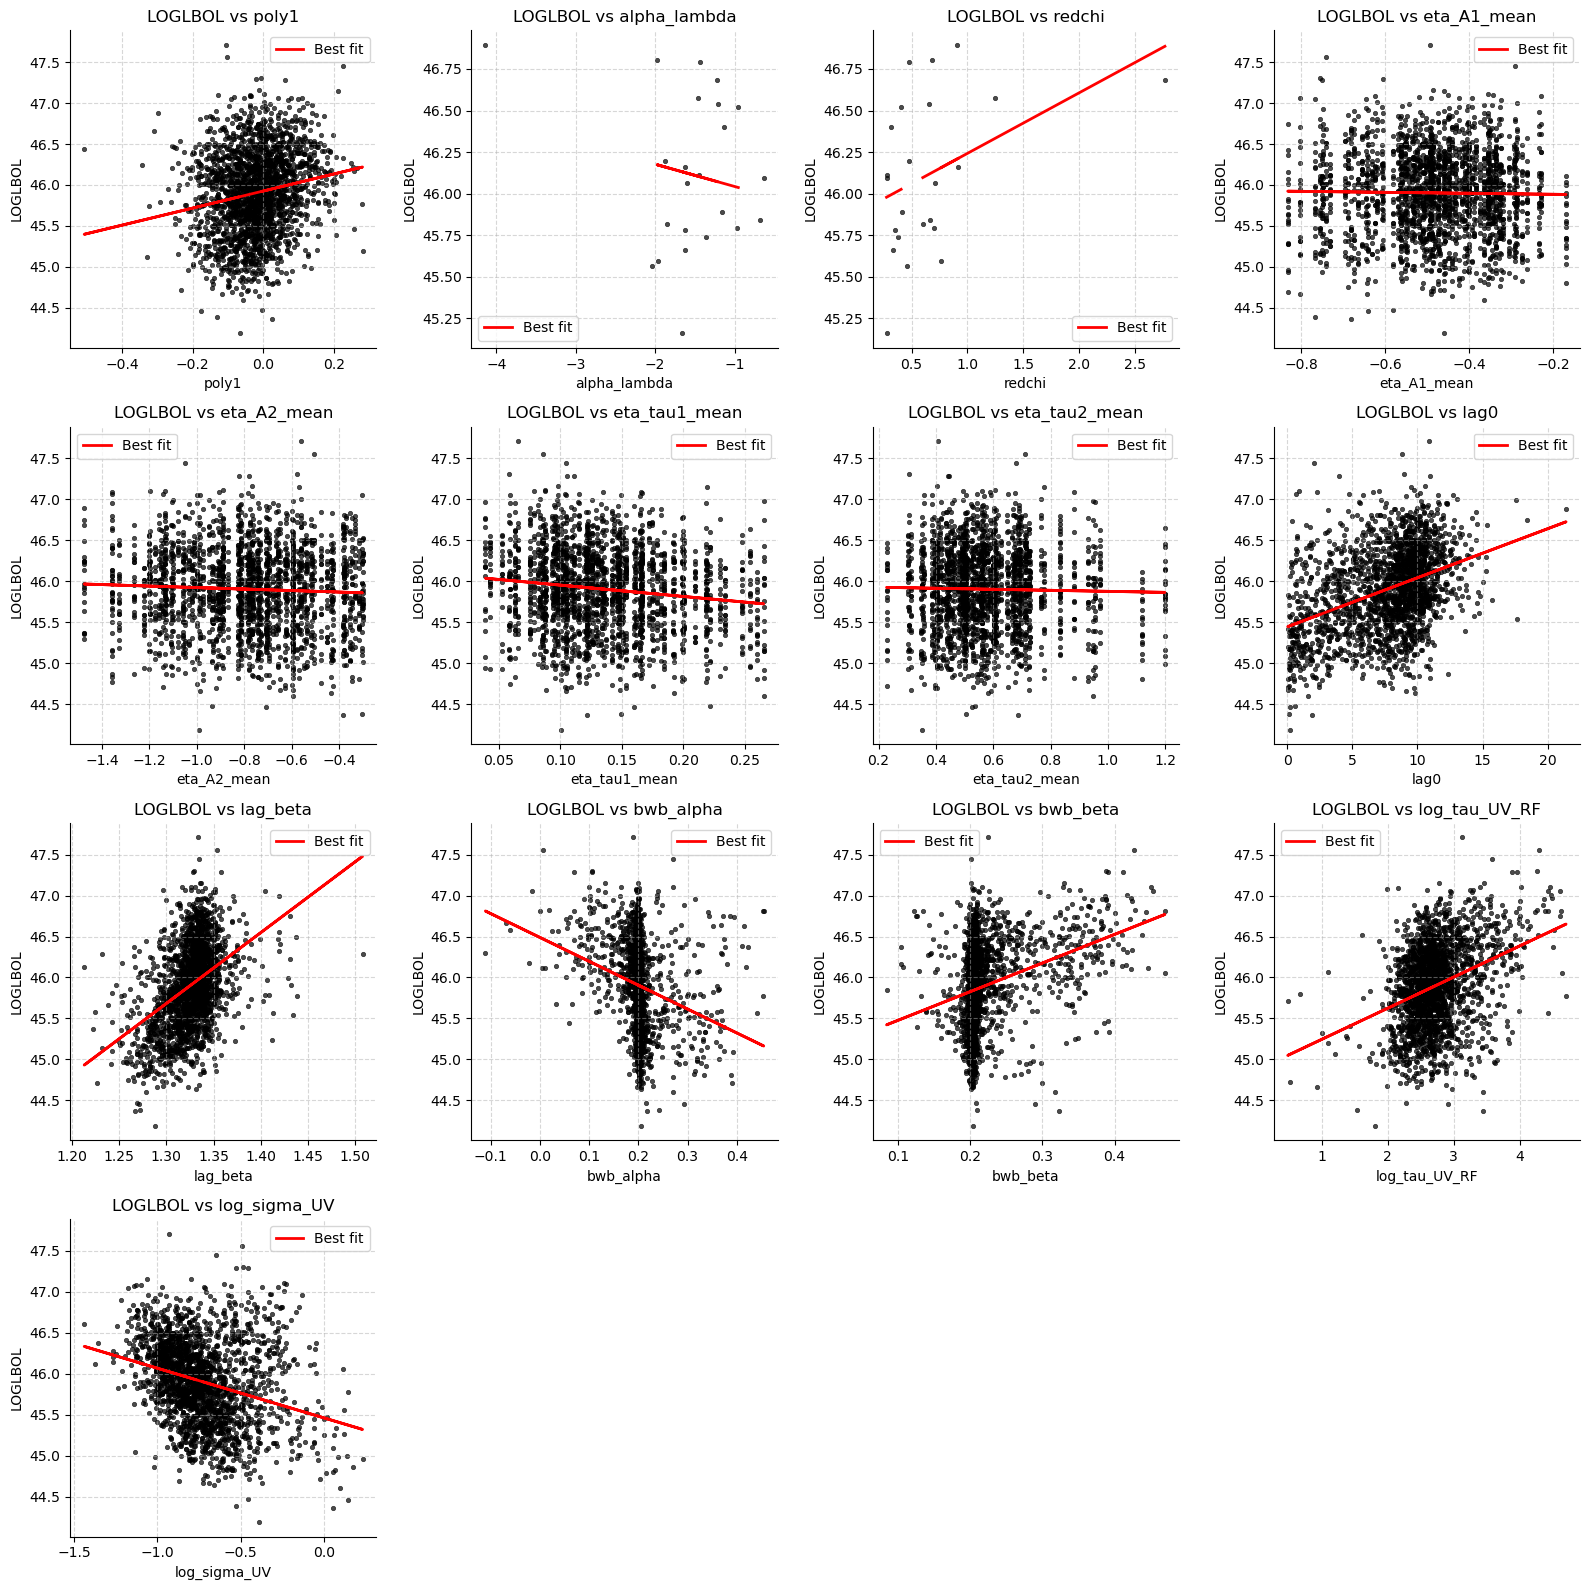

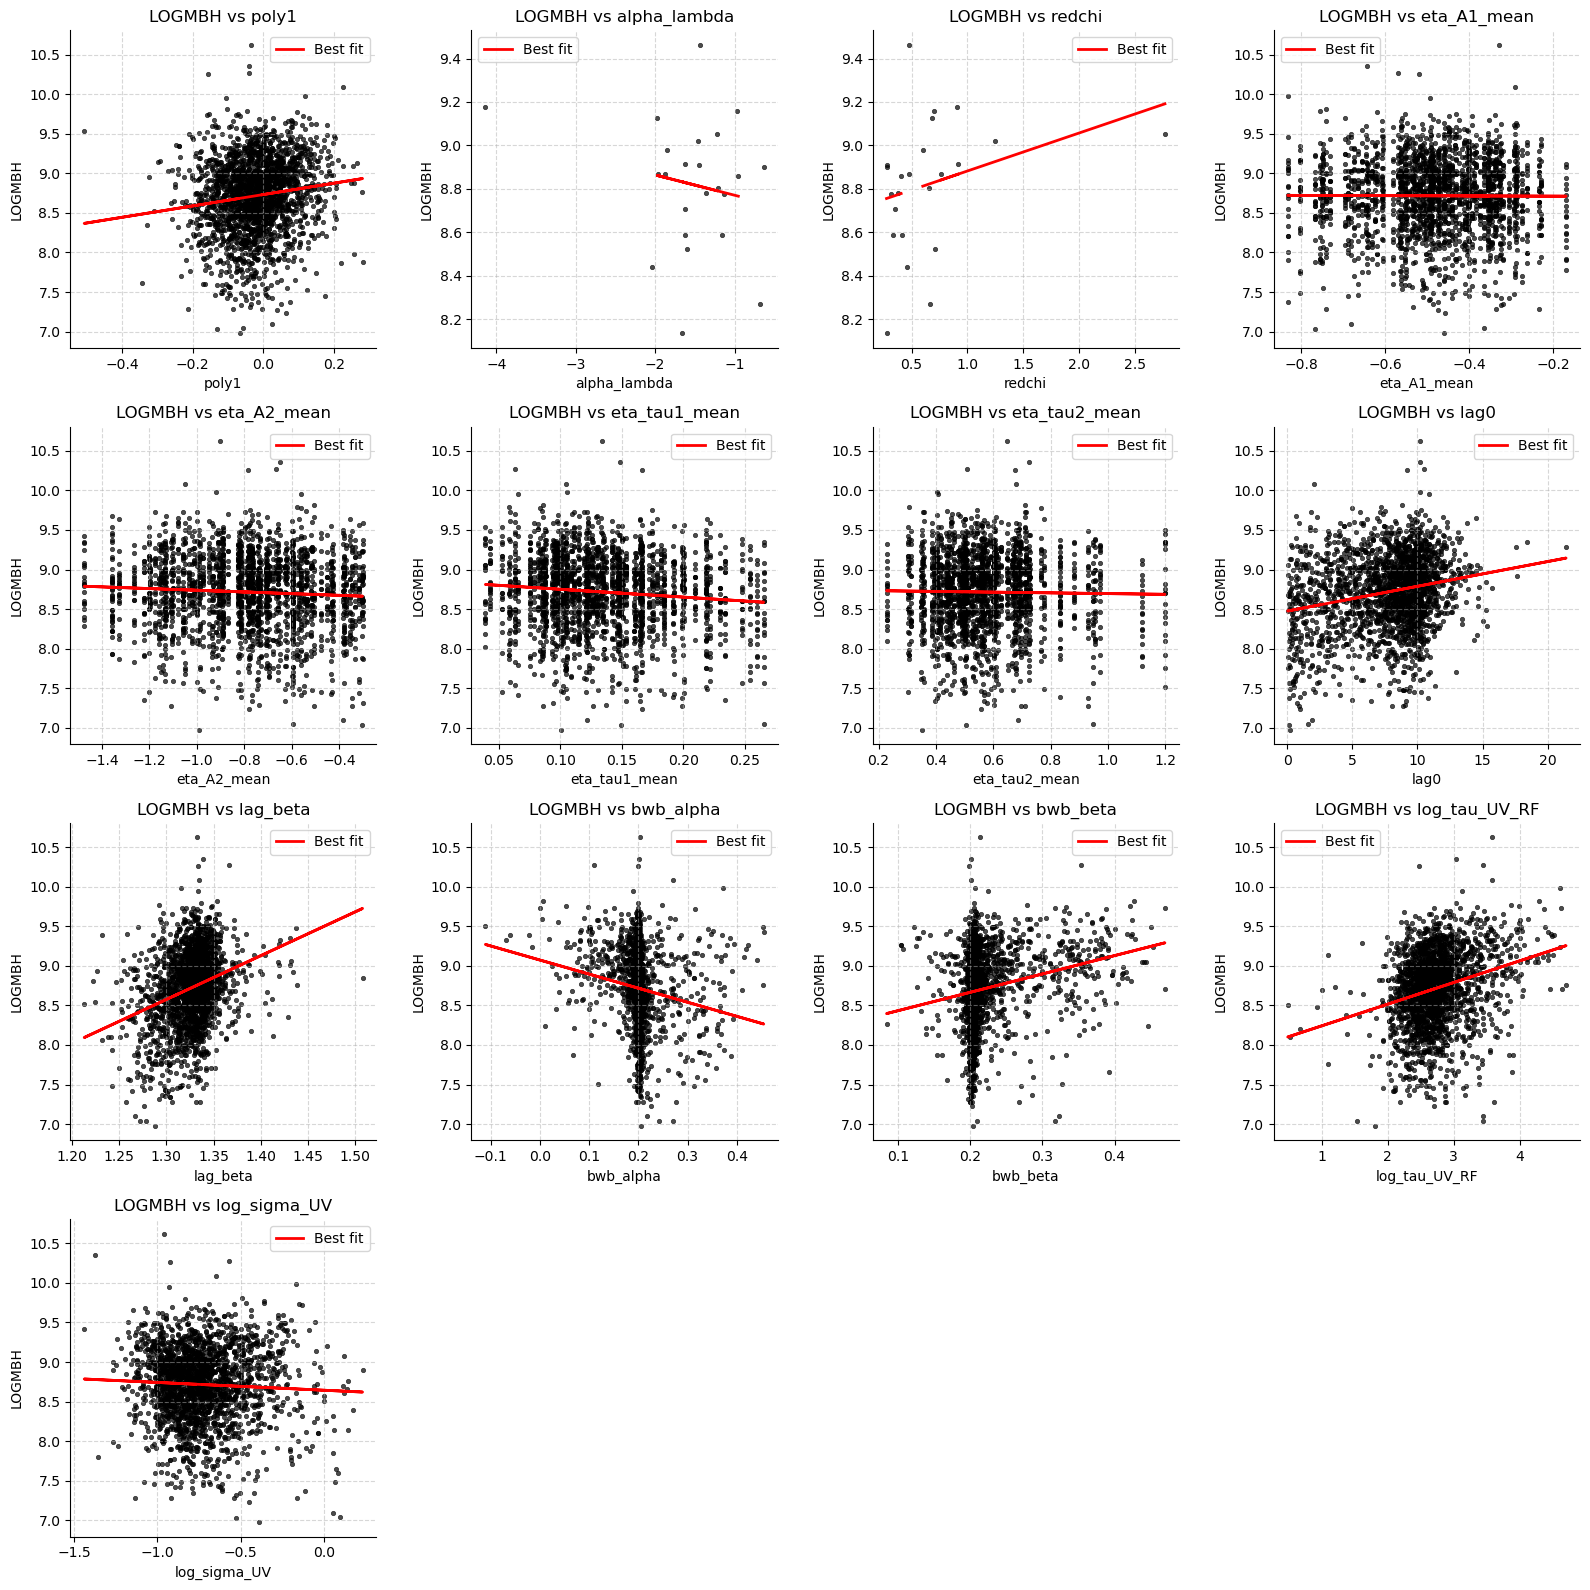

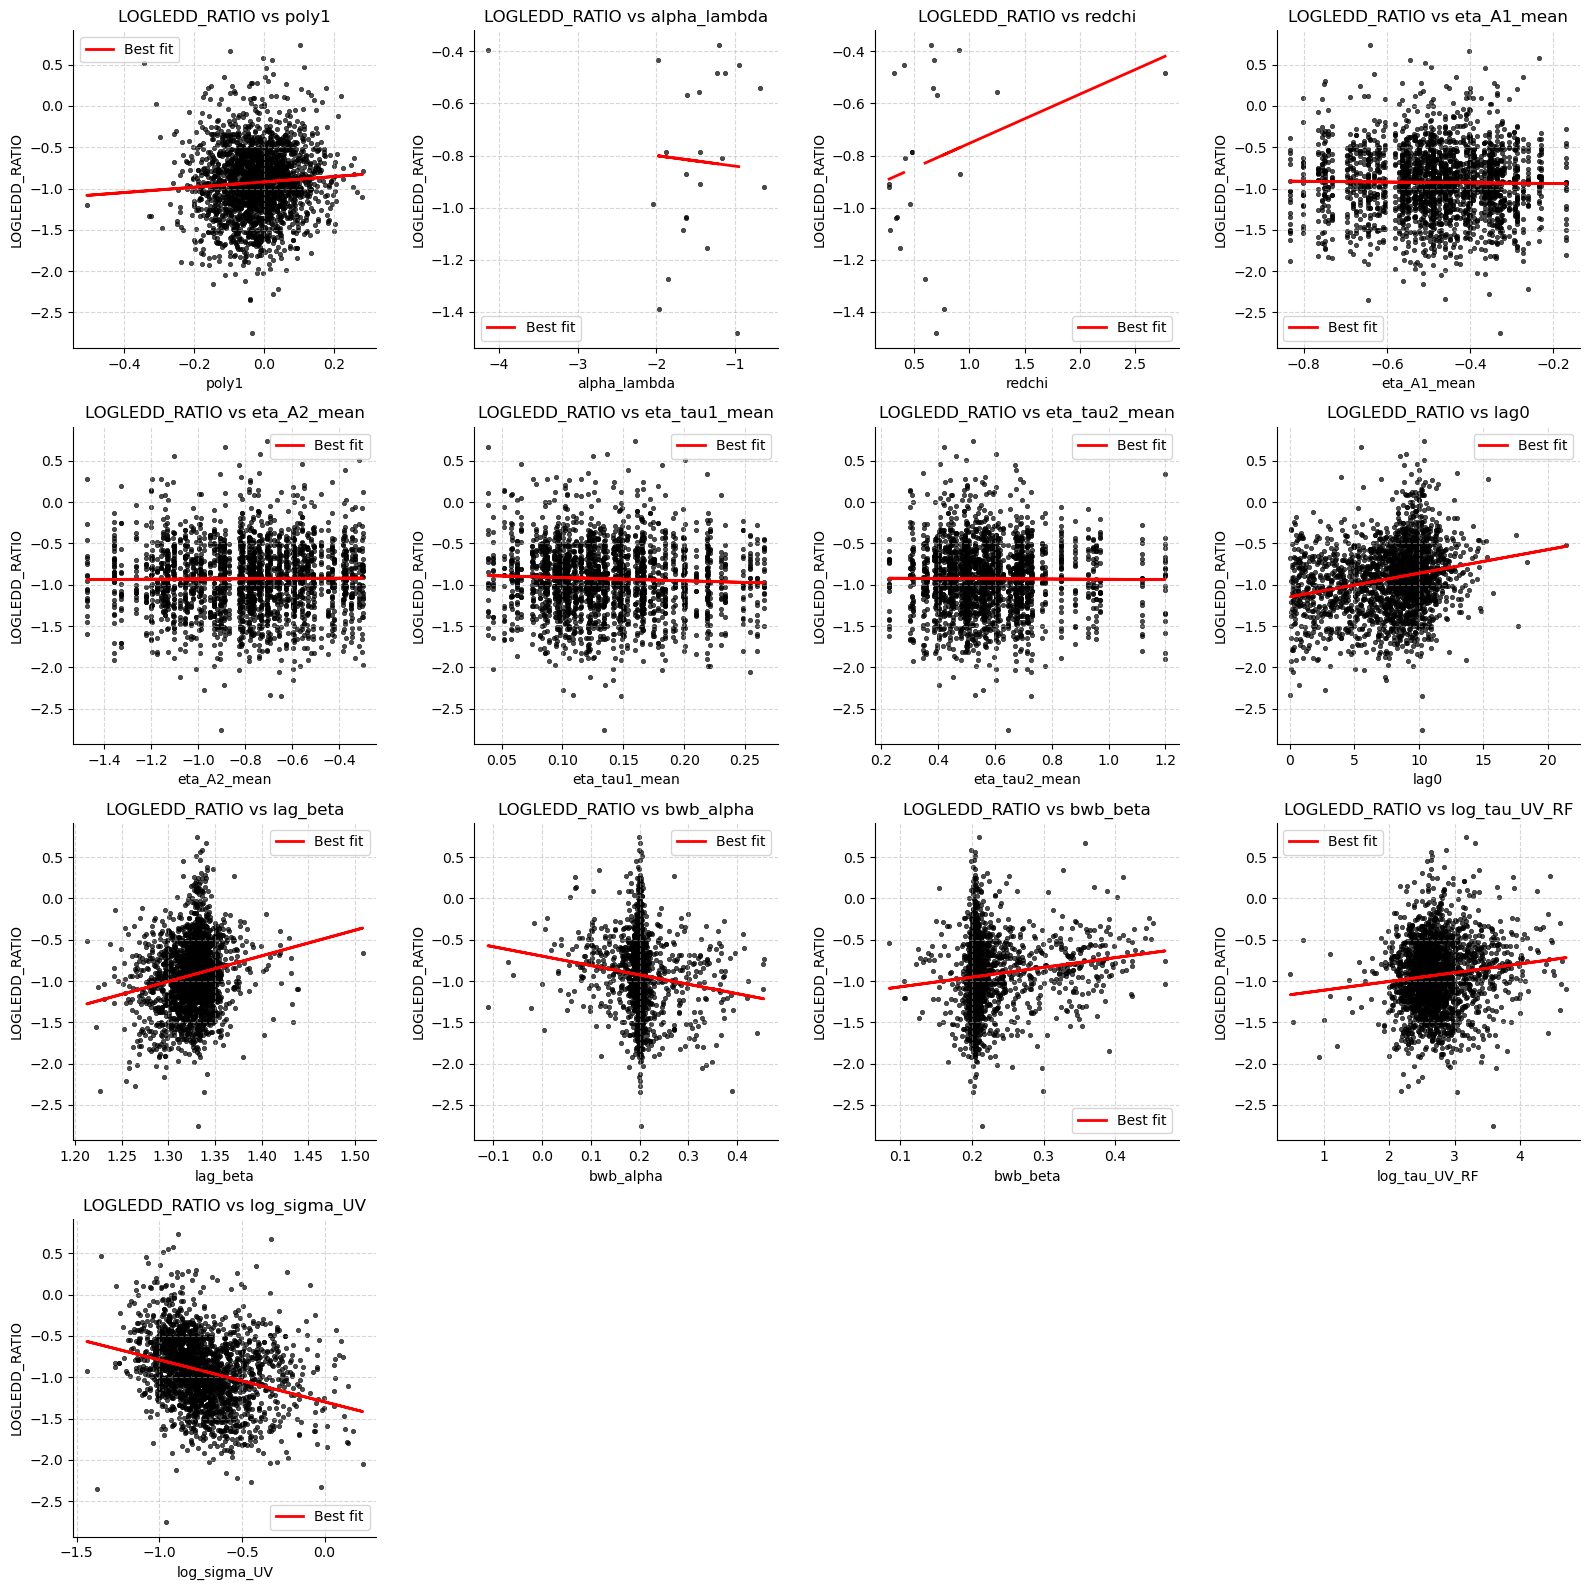

In [12]:
import math

import matplotlib.pyplot as plt

agn_df = agn_df[agn_df['LOGMBH'] > 0]  # Filter out invalid LOGMBH values

max_cols = 4
for i, key in enumerate(keys):
    n_params = len(params)
    n_cols = min(max_cols, n_params)
    n_rows = math.ceil(n_params / max_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows), squeeze=False)
    for j, param in enumerate(params):
        row, col = divmod(j, n_cols)
        ax = axes[row, col]
        x = agn_df[param]
        y = agn_df[key]
        ax.scatter(x, y,
                   s=10, alpha=0.7, edgecolor='k', facecolor='k', lw=0.5, )
        # Line of best fit
        mask = np.isfinite(x) & np.isfinite(y)
        if mask.sum() > 1:
            m, b = np.polyfit(x[mask], y[mask], 1)
            ax.plot(x, m*x + b, color='red', lw=2, label='Best fit')
            ax.legend()
        ax.set_xlabel(param)
        ax.set_ylabel(key)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.tick_params(axis='both', which='major', labelsize=10)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.set_title(f'{key} vs {param}')
    # Hide unused axes
    for j in range(n_params, n_rows * n_cols):
        row, col = divmod(j, n_cols)
        fig.delaxes(axes[row, col])
    plt.tight_layout()
    plt.show()


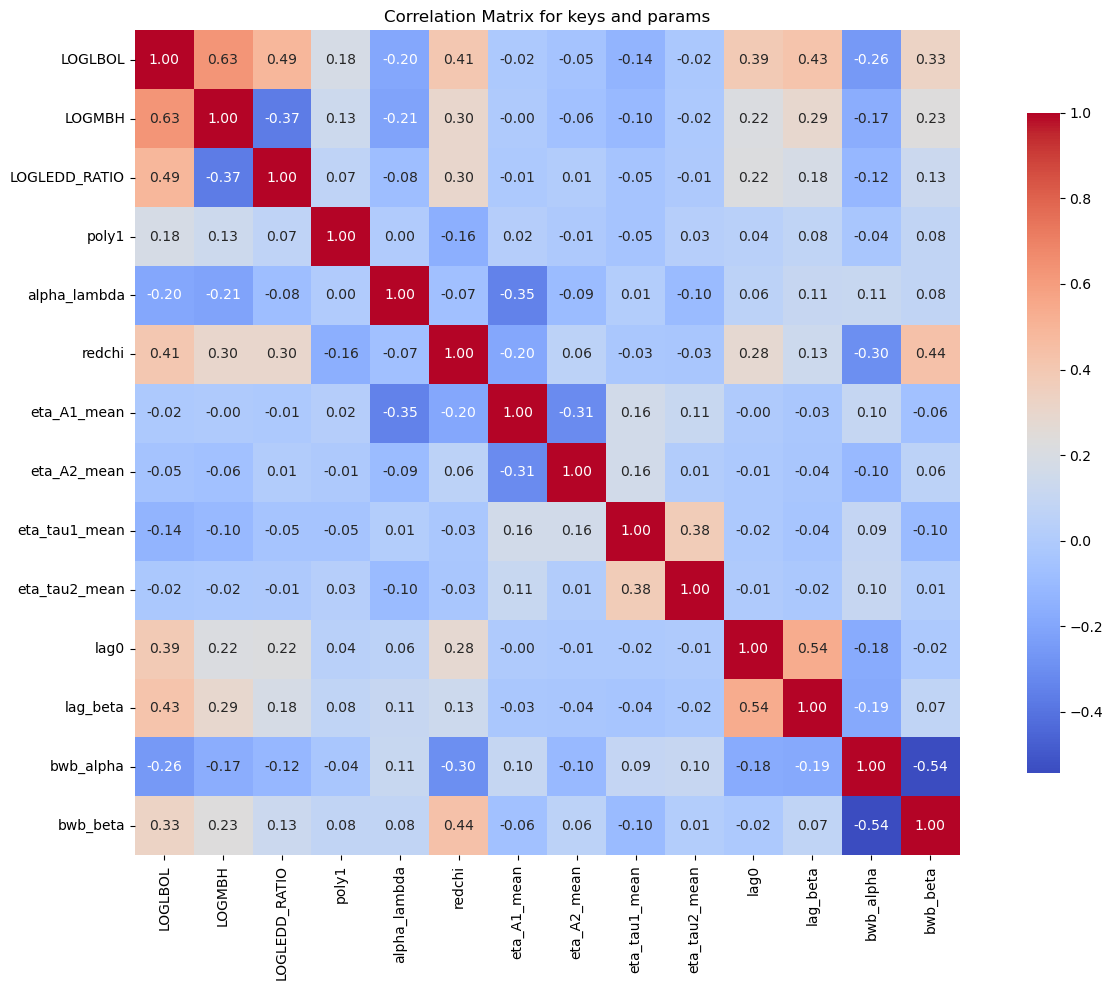

In [10]:
import seaborn as sns

# Select columns for correlation
corr_columns = keys + params
corr_df = agn_df[corr_columns]

# Compute correlation matrix
corr_matrix = corr_df.corr()

# Plot correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={'shrink': 0.8})
plt.title("Correlation Matrix for keys and params")
plt.tight_layout()
plt.show()